<a href="https://colab.research.google.com/github/furkanbal36-wq/Machine-learning-powered-used-car-price-prediction/blob/main/Machine_Learning_Powered_Used_Car_Price_Prediction_and_Smart_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Machine Learning-Powered Used Car Price Prediction and Smart Recommendation System

In [ ]:
# 0️⃣ Required Libraries

!pip install catboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings("ignore")

# Selling Price in K/M format
def price_formatter(x, pos):
    if x >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    else:
        return f'{int(x/1000)}K'

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

import ipywidgets as widgets
from IPython.display import display

sns.set(style="whitegrid")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.2 MB/s eta 0:00:00


In [ ]:
# 1️⃣ Data Loading and Overview

df = pd.read_csv('./sample_data/car.csv')
df['brand'] = df['name'].apply(lambda x: x.split(' ')[0])
df.drop('name', axis=1, inplace=True)
df['car_age'] = pd.Timestamp.now().year - df['year']

# DUPLICATE DATA ROWS AND DELETION
print("\nDuplicate Rows (first 10):")
tekrarlar = df[df.duplicated(keep=False)]
print(tekrarlar.head(10).to_string(index=False))

once = df.shape[0]

# Delete duplicate rows (keep first)
df = df.drop_duplicates()

# Number of rows after deletion
sonra = df.shape[0]

# How many were deleted?
silinen = once - sonra

print("\nDuplicate Data Cleaning:")
print("Number of rows before deletion:", once)
print("Number of rows after deletion:", sonra)
print("Number of duplicates deleted:", silinen)

print("\nDataset Shape:", df.shape)
print(df.head())

# Data Types
print("\nData Types:\n", df.dtypes)

# Missing value control
print("\nMissing Values:\n", df.isnull().sum())

# Basic statistics
print("\nStatistical Summary:\n", df.describe())

FileNotFoundError: [Errno 2] No such file or directory: './sample_data/araba.csv'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# 2️⃣ Exploratory Data Analysis (EDA)
# 1- Univariate Data Analysis

# Top 10 most expensive cars
en_pahali_10 = df.sort_values(by="selling_price", ascending=False).head(10)

print("Top 10 Most Expensive Cars:")
display(en_pahali_10)
# 1. Selling price distribution
plt.figure(figsize=(8,4))
sns.histplot(df['selling_price'], bins=30, kde=True)

plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(price_formatter))
plt.title("Selling Price Distribution")
plt.xlabel("Price (₹)")
plt.ylabel("Frequency")
plt.show()

# 2. Kilometers driven distribution
plt.figure(figsize=(8,4))
sns.histplot(df['km_driven'], bins=30, kde=True, color='orange')
plt.title("Kilometers Driven Distribution")
plt.xlabel("Kilometers")
plt.ylabel("Frequency")

# Convert X-axis to K format
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}K'))

plt.show()

# 3. Fuel type distribution
plt.figure(figsize=(6,4))
sns.countplot(x='fuel', data=df)

plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Frequency")
plt.show()

# 4. Log Transformed Selling Price Distribution
plt.figure(figsize=(8,4))
sns.histplot(np.log1p(df['selling_price']), bins=30, kde=True)

plt.title("Log Transformed Selling Price Distribution")
plt.xlabel("Selling Price (Log Scale)")
plt.ylabel("Frequency")
plt.show()

NameError: name 'df' is not defined

In [ ]:
# 2- Bivariate Data Analysis

# 1. Average Selling Price by KM Range

# Writing KM from 0K to 900K in 100K intervals.
bins = np.arange(0, 900001, 100000)
df['km_bin'] = pd.cut(df['km_driven'], bins=bins)

plt.figure(figsize=(12,6))
sns.barplot(x='km_bin', y='selling_price', data=df)

# X-axis: KM in K format
new_labels = []
for interval in df['km_bin'].cat.categories:
    start = int(interval.left / 1000)
    end = int(interval.right / 1000)
    new_labels.append(f'{start}K-{end}K')

plt.xticks(ticks=range(len(new_labels)), labels=new_labels, rotation=45)

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(price_formatter))

plt.title("Average Selling Price by KM Range")
plt.xlabel("Kilometer Range")
plt.ylabel("Selling Price")
plt.show()

# 2. Impact of Features on Price
plt.figure(figsize=(8,5))
sns.barplot(x='transmission', y='selling_price', data=df)


plt.xticks(ticks=[0,1], labels=['Manual','Automatic'])

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(price_formatter))

plt.title("Average Price by Transmission")
plt.xlabel("Transmission Type")
plt.ylabel("Selling Price")
plt.show()

# Convert X-axis to string
# df['fuel_str'] = df['fuel'].map(lambda x: encoders['fuel'].inverse_transform([x])[0]) # Removed

plt.figure(figsize=(8,5))
sns.barplot(x='fuel', y='selling_price', data=df) # 'fuel_str' instead of 'fuel' was used

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(price_formatter))

plt.title("Average Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.show()

# Selling price distribution by fuel type (Box Plot)
plt.figure(figsize=(10,6))
x_fuel = df['fuel'] # inverse_transform removed
sns.boxplot(x=x_fuel, y='selling_price', data=df, palette='viridis', hue=x_fuel, legend=False)
plt.title('Selling Price Distribution by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price (₹)')
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(price_formatter)) # Apply formatter
plt.show()

# Selling price distribution by transmission type (Box Plot)
plt.figure(figsize=(8,5))
x_transmission = df['transmission'] # inverse_transform removed
sns.boxplot(x=x_transmission, y='selling_price', data=df, palette='plasma', hue=x_transmission, legend=False)
plt.title('Selling Price Distribution by Transmission Type')
plt.xlabel('Transmission Type')
plt.ylabel('Selling Price (₹)')
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(price_formatter)) # Apply formatter
plt.show()

# Selling price distribution by number of owners (Box Plot)
plt.figure(figsize=(10,6))
x_owner = df['owner'] # inverse_transform removed
sns.boxplot(x=x_owner, y='selling_price', data=df, palette='cividis', hue=x_owner, legend=False)
plt.title('Selling Price Distribution by Number of Owners')
plt.xlabel('Number of Owners')
plt.ylabel('Selling Price (₹)')
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(price_formatter)) # Apply formatter
plt.show()

# Average selling price by brand (top 10 brands) (Bar Chart)
top_brands = df['brand'].value_counts().head(10).index
df_top_brands = df[df['brand'].isin(top_brands)]

plt.figure(figsize=(14,7))
x_brand = df_top_brands['brand'] # inverse_transform removed
sns.barplot(x=x_brand, y='selling_price', data=df_top_brands, estimator=np.mean, palette='magma', order=df_top_brands.groupby('brand')['selling_price'].mean().sort_values(ascending=False).index, hue=x_brand, legend=False)
plt.title('Average Selling Price of Top 10 Best-Selling Brands')
plt.xlabel('Brand')
plt.ylabel('Average Selling Price (₹)')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(price_formatter)) # Apply formatter
plt.show()

NameError: name 'df' is not defined

In [ ]:
# 3- Multivariate Data Analysis
cols = ['year','km_driven','selling_price']

g = sns.pairplot(df[cols], diag_kind='kde')

tr_isim = {
    'year':'Year',
    'km_driven':'Kilometers',
    'selling_price':'Selling Price'
}

for i, var in enumerate(cols):
    for j, var2 in enumerate(cols):

        ax = g.axes[i, j]

        # X-axis label
        ax.set_xlabel(tr_isim[var2])

        # Y-axis label
        ax.set_ylabel(tr_isim[var])

        # Converting 1000 to "K".
        if var == 'km_driven':
            ax.yaxis.set_major_formatter(
                ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}K')
            )

        if var2 == 'km_driven':
            ax.xaxis.set_major_formatter(
                ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}K')
            )

        # Selling Price for y-axis in K/M format
        if var == 'selling_price':
            ax.yaxis.set_major_formatter(ticker.FuncFormatter(price_formatter))


plt.show()

NameError: name 'df' is not defined

In [ ]:
# 4- Car Age and Selling Price Chart
df['car_age'] = pd.Timestamp.now().year - df['year']

plt.figure(figsize=(10,6))
sns.scatterplot(x='car_age', y='selling_price', data=df)

# Y-axis: Selling Price in K/M format
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(price_formatter))

plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.show()

NameError: name 'df' is not defined

In [ ]:
# 5- Correlation matrix
plt.figure(figsize=(8,6))
sns.heatmap(df[['year','km_driven','selling_price']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation of Numerical Variables")
plt.show()

NameError: name 'df' is not defined

<Figure size 800x600 with 0 Axes>

In [ ]:
# 3️⃣ Data Structure and Imbalance Control

print("\nDistribution of categorical variables:")
for col in ['fuel','transmission','owner','brand']:
    print(f"\n{col} distribution:")
    print(df[col].value_counts())


Distribution of categorical variables:

fuel distribution:


NameError: name 'df' is not defined

In [ ]:
# 3.5- Remove temporary "_bin" columns to avoid confusion
if 'km_bin' in df.columns:
    df.drop('km_bin', axis=1, inplace=True)
    print("Dropped 'km_bin' column from df.")
else:
    print("'km_bin' column not found in df, no action taken.")

print(df.head())

NameError: name 'df' is not defined

In [ ]:
# 4️⃣ Preprocessing and Feature Engineering

# Identify categorical columns for One-Hot Encoding.
categorical_cols = ['fuel', 'transmission', 'owner', 'brand', 'seller_type']

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

# Display the first 5 rows and shape of the new DataFrame.
print("DataFrame after One-Hot Encoding:")
print(df_encoded[['year', 'selling_price', 'km_driven', 'fuel_Diesel', 'transmission_Manual', 'brand_Maruti']].head())
print("New Dataset Shape:", df_encoded.shape)

NameError: name 'df' is not defined

In [ ]:
# X and Y definition
X = df_encoded.drop('selling_price', axis=1)
y = df_encoded['selling_price']

NameError: name 'df_encoded' is not defined

In [ ]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

NameError: name 'X' is not defined

In [ ]:
# 1. CatBoostRegressor Model Training
cb = CatBoostRegressor(random_state=42, verbose=0) # verbose=0 to suppress output during training

# Define hyperparameter range
param_distributions_cb = {
    'iterations': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'depth': [4, 6, 8, 10],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'border_count': [32, 64, 128, 254]
}
# Initialize RandomizedSearchCV object for Catboost
random_search_cb = RandomizedSearchCV(estimator=cb, param_distributions=param_distributions_cb,
                                   n_iter=50, cv=3, verbose=2, random_state=42, n_jobs=-1, scoring='r2')

# Perform hyperparameter optimization
random_search_cb.fit(X_train, y_train)

# Get the best model
model_cb = random_search_cb.best_estimator_

print("Best parameters (CatBoost RandomizedSearchCV):", random_search_cb.best_params_)

NameError: name 'X_train' is not defined

In [ ]:
# 1. CatboostRegressor model performance.
y_pred_cb = model_cb.predict(X_test)

r2_cb = r2_score(y_test, y_pred_cb)
rmse_cb = np.sqrt(mean_squared_error(y_test, y_pred_cb))
mae_cb = mean_absolute_error(y_test, y_pred_cb)

print("R2 (CatBoost RandomizedSearchCV):", r2_cb)
print("RMSE (CatBoost RandomizedSearchCV):", rmse_cb)
print("MAE (CatBoost RandomizedSearchCV):", mae_cb)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_cb, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (CatBoost with OHE)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.grid(True)
plt.show()

NameError: name 'model_cb' is not defined

In [ ]:
# 2. RandomForestRegressor Model Training

rf = RandomForestRegressor(random_state=42)


param_distributions = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [10, 20, 30, 40, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_distributions,
                                   n_iter=50, cv=3, verbose=2, random_state=42, n_jobs=-1, scoring='r2')


random_search.fit(X_train, y_train)


model_random = random_search.best_estimator_

print("Best parameters (RandomizedSearchCV):", random_search.best_params_)

NameError: name 'X_train' is not defined

In [ ]:
# 2. RandomForestRegressor model performance.
y_pred_random = model_random.predict(X_test)

r2_random = r2_score(y_test, y_pred_random)
rmse_random = np.sqrt(mean_squared_error(y_test, y_pred_random))
mae_random = mean_absolute_error(y_test, y_pred_random)

print("R2 (RandomizedSearchCV):", r2_random)
print("RMSE (RandomizedSearchCV):", rmse_random)
print("MAE (RandomizedSearchCV):", mae_random)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_random, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (Random Forest with OHE)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.grid(True)
plt.show()

NameError: name 'model_random' is not defined

In [ ]:
# 3. LightGBM Model Training
lgbm = LGBMRegressor(random_state=42, n_jobs=-1)


param_distributions_lgbm = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [10, 20, 30, 40, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [0, 0.1, 0.5, 1.0]
}
random_search_lgbm = RandomizedSearchCV(estimator=lgbm, param_distributions=param_distributions_lgbm,
                                   n_iter=50, cv=3, verbose=2, random_state=42, n_jobs=-1, scoring='r2')


random_search_lgbm.fit(X_train, y_train)


model_lgbm = random_search_lgbm.best_estimator_

print("Best parameters (LightGBM RandomizedSearchCV):", random_search_lgbm.best_params_)

NameError: name 'X_train' is not defined

In [ ]:
# 3. LightGBM model performance.
y_pred_lgbm = model_lgbm.predict(X_test)

r2_lgbm = r2_score(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)

print("R2 (LightGBM RandomizedSearchCV):", r2_lgbm)
print("RMSE (LightGBM RandomizedSearchCV):", rmse_lgbm)
print("MAE (LightGBM RandomizedSearchCV):", mae_lgbm)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lgbm, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (LightGBM with OHE)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.grid(True)
plt.show()

NameError: name 'model_lgbm' is not defined

NameError: name 'df_encoded' is not defined

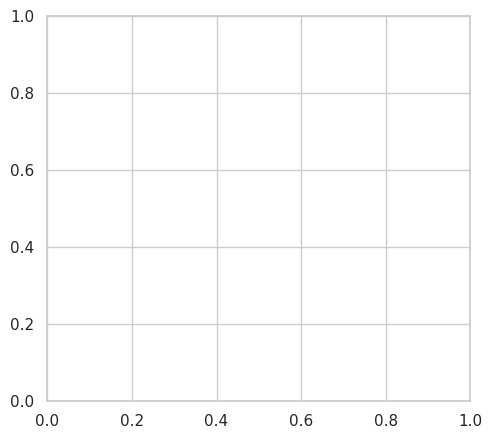

In [ ]:
# 5️⃣Outlier Detection and Cleaning

# 1. Create box plots for 'selling_price' and 'km_driven' columns to visually analyze outliers.
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df_encoded['selling_price'])
plt.title('Selling Price Distribution (Box Plot)')
plt.ylabel('Selling Price')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_encoded['km_driven'])
plt.title('Kilometer Distribution (Box Plot)')
plt.ylabel('Kilometers')

plt.tight_layout()
plt.show()

In [ ]:
# 2. Calculation of Outlier Bounds Using IQR Method

# Q1 (25th percentile) is calculated for the selling_price variable
Q1_price = df_encoded['selling_price'].quantile(0.25)

Q3_price = df_encoded['selling_price'].quantile(0.75)

# IQR (Interquartile Range) is calculated
IQR_price = Q3_price - Q1_price

# The lower bound is calculated (below this value is considered an outlier)
lower_bound_price = Q1_price - 1.5 * IQR_price

# The upper bound is calculated (above this value is considered an outlier)
upper_bound_price = Q3_price + 1.5 * IQR_price


# Q1 is calculated for the km_driven variable
Q1_km = df_encoded['km_driven'].quantile(0.25)

# Q3 is calculated for the km_driven variable
Q3_km = df_encoded['km_driven'].quantile(0.75)

# IQR is calculated
IQR_km = Q3_km - Q1_km

# The lower bound is calculated
lower_bound_km = Q1_km - 1.5 * IQR_km

# The upper bound is calculated
upper_bound_km = Q3_km + 1.5 * IQR_km


# The calculated outlier bounds are printed to the screen
print(f"Selling Price Outlier Bounds: Lower={lower_bound_price:.2f}, Upper={upper_bound_price:.2f}")
print(f"KM Driven Outlier Bounds: Lower={lower_bound_km:.2f}, Upper={upper_bound_km:.2f}")

NameError: name 'df_encoded' is not defined

In [ ]:
# 3. Capping Outliers in Selling Price and Kilometers Driven
df_cleaned = df_encoded.copy()

# Cap extreme values for 'selling_price'
df_cleaned['selling_price'] = np.where(
    df_cleaned['selling_price'] < lower_bound_price, lower_bound_price,
    np.where(df_cleaned['selling_price'] > upper_bound_price, upper_bound_price,
             df_cleaned['selling_price']
    )
)

# Cap extreme values for 'km_driven'
df_cleaned['km_driven'] = np.where(
    df_cleaned['km_driven'] < lower_bound_km, lower_bound_km,
    np.where(df_cleaned['km_driven'] > upper_bound_km, upper_bound_km,
             df_cleaned['km_driven']
    )
)

print("Extreme values in 'selling_price' and 'km_driven' columns have been capped.")

NameError: name 'df_encoded' is not defined

NameError: name 'df_cleaned' is not defined

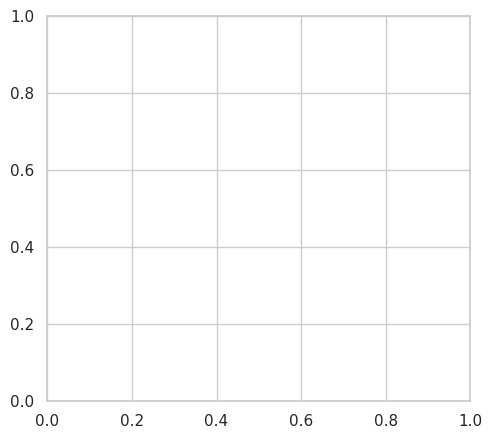

In [ ]:
# 4. Selling Price and Kilometers Driven Distribution (Outliers Capped)

# Adjusting graph size
plt.figure(figsize=(12, 5))

# 1. Subplot: Selling Price Distribution
plt.subplot(1, 2, 1)
sns.boxplot(y=df_cleaned['selling_price'])
plt.title('Selling Price Distribution (Capped Outliers)')
plt.ylabel('Selling Price')

# 2. Subplot: Kilometers Driven Distribution
plt.subplot(1, 2, 2)
sns.boxplot(y=df_cleaned['km_driven'])
plt.title('Kilometers Driven Distribution (Capped Outliers)')
plt.ylabel('Kilometers')

plt.tight_layout()
plt.show()

In [ ]:
# 6️⃣ X and Y definition
X = df_cleaned.drop('selling_price', axis=1)
y = df_cleaned['selling_price']

X_cols_for_prediction = X.columns.tolist()

NameError: name 'df_cleaned' is not defined

In [ ]:
# 7️⃣Train/Test Split with Capped Data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

NameError: name 'X' is not defined

In [ ]:
# 8️⃣ Scaling Numerical Features and Adding to Train/Test Sets

numerical_cols = ['year', 'km_driven']

# Initialize StandardScaler and fit to training data, transform test data
scaler = StandardScaler()
X_train_scaled_numerical = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled_numerical = scaler.transform(X_test[numerical_cols])

# Convert scaled numerical data to DataFrame
X_train_scaled_numerical_df = pd.DataFrame(X_train_scaled_numerical, columns=numerical_cols, index=X_train.index)
X_test_scaled_numerical_df = pd.DataFrame(X_test_scaled_numerical, columns=numerical_cols, index=X_test.index)

# Combine with categorical columns to create the final dataset
X_train_scaled = pd.concat([X_train_scaled_numerical_df, X_train.drop(columns=numerical_cols)], axis=1)
X_test_scaled = pd.concat([X_test_scaled_numerical_df, X_test.drop(columns=numerical_cols)], axis=1)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("\nX_train_scaled first 5 rows:")
print(X_train_scaled.head())
print("\nX_test_scaled first 5 rows:")
print(X_test_scaled.head())

NameError: name 'X_train' is not defined

In [ ]:
# 4. XGBRegressor Model Training
xgb_scaled = XGBRegressor(random_state=42, tree_method='hist')


param_distributions_xgb = {
    'n_estimators': [100, 200, 300,400,500],
    'max_depth': [3, 5, 7, 9, 11],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3]
}


random_search_xgb_scaled = RandomizedSearchCV(estimator=xgb_scaled, param_distributions=param_distributions_xgb,
                                   n_iter=50, cv=3, verbose=2, random_state=42, n_jobs=-1, scoring='r2')


random_search_xgb_scaled.fit(X_train_scaled, y_train)


model_xgb_scaled = random_search_xgb_scaled.best_estimator_


print("Best parameters (XGBoost RandomizedSearchCV - Scaled Data):", random_search_xgb_scaled.best_params_)

NameError: name 'X_train_scaled' is not defined

In [ ]:
# 9️⃣ Model Comparison

In [ ]:
# 4. XGBRegressor model performance.
y_pred_xgb_scaled = model_xgb_scaled.predict(X_test_scaled)

r2_xgb_scaled = r2_score(y_test, y_pred_xgb_scaled)
rmse_xgb_scaled = np.sqrt(mean_squared_error(y_test, y_pred_xgb_scaled))
mae_xgb_scaled = mean_absolute_error(y_test, y_pred_xgb_scaled)

print("R2 (XGBoost RandomizedSearchCV - Scaled Data):", r2_xgb_scaled)
print("RMSE (XGBoost RandomizedSearchCV - Scaled Data):", rmse_xgb_scaled)
print("MAE (XGBoost RandomizedSearchCV - Scaled Data):", mae_xgb_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb_scaled, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (XGBoost with OHE and Scaling)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.grid(True)
plt.show()

NameError: name 'model_xgb_scaled' is not defined


### Model Performance Summary Table:

| Model                        | R2 Score | RMSE (₹)     | MAE (₹)      |
|:-----------------------------|:---------|:-------------|:-------------|
| Random Forest (OHE)          | 0.7140   | 295427.85    | 114113.33    |
| LightGBM (OHE)               | 0.6515   | 326113.26    | 143196.37    |
| CatBoost (OHE)               | 0.7281   | 288033.70    | 124414.41    |
| XGBoost (OHE + Scaled)       | **0.8037** | **135911.12**| **95120.05** |

### Conclusion and Best Model:

 **XGBoost (OHE + Scaled)** R2 Score (**0.8037**) RMSE (**135911.12 ₹**) MAE (**95120.05 ₹**)


In [ ]:
# 🔟 AI Recommendation Function

# Helper function: Process given car DataFrame and prepare for prediction
def _process_cars_for_prediction(cars_df_subset):
    # Create a deep copy to avoid modifying the original subset
    temp_for_pred = cars_df_subset.copy()

    # Cap extreme values for km_driven with pre-calculated bounds
    temp_for_pred['km_driven'] = np.where(
        temp_for_pred['km_driven'] < lower_bound_km, lower_bound_km,
        np.where(temp_for_pred['km_driven'] > upper_bound_km, upper_bound_km,
                 temp_for_pred['km_driven']
        )
    )

    # Write capped km_driven values back to the original subset
    cars_df_subset['km_driven'] = temp_for_pred['km_driven']

    # 1. Convert categorical columns to numerical with One-Hot Encoding
    categorical_cols_for_ohe = ['fuel', 'transmission', 'owner', 'brand', 'seller_type']
    temp_for_pred = pd.get_dummies(temp_for_pred, columns=categorical_cols_for_ohe, drop_first=True, dtype=int)

    # 2. Align with columns expected by the model
    missing_cols = set(X_cols_for_prediction) - set(temp_for_pred.columns)
    for c in missing_cols:
        temp_for_pred[c] = 0
    extra_cols = set(temp_for_pred.columns) - set(X_cols_for_prediction)
    if len(extra_cols) > 0:
        temp_for_pred = temp_for_pred.drop(columns=list(extra_cols))

    # Make column order the same as the model
    temp_for_pred = temp_for_pred[X_cols_for_prediction]

    # 3. Scale numerical columns ('year', 'km_driven')
    numerical_cols = ['year', 'km_driven']
    temp_for_pred[numerical_cols] = scaler.transform(temp_for_pred[numerical_cols])

    # Make predictions with the model
    temp_predictions = model_xgb_scaled.predict(temp_for_pred)
    cars_df_subset['tahmini_fiyat'] = temp_predictions

    # Normalize by taking max/min values from df_cleaned
    max_km_driven_global = df_cleaned['km_driven'].max()
    min_year_global = df_cleaned['year'].min()
    max_year_global = df_cleaned['year'].max()

    # Price ratio (predicted / selling price)
    cars_df_subset['fiyat_orani'] = cars_df_subset['tahmini_fiyat'] / cars_df_subset['selling_price']

    # Calculate reasonableness score (between 0-1)
    cars_df_subset['mantiklilik'] = (
        0.5 * (cars_df_subset['fiyat_orani']) +
        0.3 * (1 - (cars_df_subset['km_driven'] / max_km_driven_global)) +
        0.2 * ((cars_df_subset['year'] - min_year_global) / (max_year_global - min_year_global))
    )
    return cars_df_subset

# Main AI recommendation function
def ai_oner(amac, transmission_input=None, fuel_input=None, owner_input=None):

    temp = df.copy() # Filter on original df

    # Apply filter based on user input
    if transmission_input != "Farketmez":
        temp = temp[temp['transmission'] == transmission_input]
    if fuel_input != "Farketmez":
        temp = temp[temp['fuel'] == fuel_input]
    if owner_input != "Farketmez":
        temp = temp[temp['owner'] == owner_input]

    # Warn if no cars remain after filtering
    if len(temp) == 0:
        return "No suitable car found"

    # Prepare cars for prediction and reasonableness score
    temp = _process_cars_for_prediction(temp)

    # Purpose-based recommendation
    if amac == "Ekonomik":
        # Select top 5 cars based on reasonableness score
        return temp.sort_values('mantiklilik', ascending=False).head(5)
    elif amac == "Orta Sınıf":
        # Selection based on price proximity to selling price
        temp['denge'] = abs(temp['fiyat_orani'] - 1)
        return temp.sort_values('denge').head(5)
    elif amac == "Lüks":
        # Select top 5 cars with highest predicted price
        return temp.sort_values('tahmini_fiyat', ascending=False).head(5)

In [ ]:
# ⏸️ AI Recommendation Interface

# Dropdown for user to select purpose (Economic, Mid-Range, Luxury)
w_amac = widgets.Dropdown(
    options=['Economic', 'Mid-Range', 'Luxury'],
    value='Economic',
    description='Purpose:'
)

# Dropdown to select transmission type
w_transmission = widgets.Dropdown(
    options=['Does not matter'] + sorted(df['transmission'].unique().tolist()),
    value='Does not matter',
    description='Transmission:'
)

# Dropdown to select fuel type
w_fuel = widgets.Dropdown(
    options=['Does not matter'] + sorted(df['fuel'].unique().tolist()),
    value='Does not matter',
    description='Fuel Type:'
)

# Dropdown to select number of owners
w_owner = widgets.Dropdown(
    options=['Does not matter'] + sorted(df['owner'].unique().tolist()),
    value='Does not matter',
    description='Number of Owners:'
)

# Get Recommendation button
btn = widgets.Button(description="Get Recommendation")

# Button to select 10 random brands
btn_random_brands = widgets.Button(description="Random 10 Brands")

# Widget to display output
out = widgets.Output()

# Function to run when recommendation button is clicked
def tikla(b):
    out.clear_output()  # Clear previous output first
    with out:
        # Call AI recommendation function
        sonuc = ai_oner(w_amac.value, w_transmission.value, w_fuel.value, w_owner.value)

        if isinstance(sonuc,str):
            # If the result is a string (no suitable car), print the message
            print(sonuc)
        else:
            # Format numbers: ₹ symbol and thousand separator
            sonuc['selling_price'] = sonuc['selling_price'].apply(lambda x: f"₹{x:,.0f}".replace(",", "."))
            sonuc['tahmini_fiyat'] = sonuc['tahmini_fiyat'].apply(lambda x: f"₹{x:,.0f}".replace(",", "."))
            sonuc['km_driven'] = sonuc['km_driven'].apply(lambda x: f"{x:,.0f}".replace(",", "."))
            sonuc['mantiklilik'] = sonuc['mantiklilik'].round(3)  # Round reasonableness score to 3 decimal places

            # Display the result DataFrame
            display(sonuc[[
                'year',
                'selling_price',
                'tahmini_fiyat',
                'mantiklilik',
                'km_driven',
                'fuel',
                'transmission',
                'owner',
                'brand'
            ]])

# Function to run when random 5 brands button is clicked
def tikla_random_brands(b):
    out.clear_output()  # Clear previous output
    with out:
        if 'brand' not in df.columns:
            print("Brand column not found.")
            return

        # Get unique brands
        unique_brands = df['brand'].unique().tolist()
        if len(unique_brands) < 5:
            print("Not enough unique brands found.")
            return

        # Select 10 random brands
        random_brands = np.random.choice(unique_brands, 10, replace=False)

        random_cars_list = []
        for brand_name in random_brands:
            # Select a random car from each brand
            brand_cars = df[df['brand'] == brand_name]
            if not brand_cars.empty:
                random_car = brand_cars.sample(1, random_state=np.random.randint(0, 1000)).iloc[0]
                random_cars_list.append(random_car)

        if not random_cars_list:
            print("No random car found.")
            return

        # Convert selected cars to DataFrame
        random_cars_df = pd.DataFrame(random_cars_list).reset_index(drop=True)

        # Prediction and score calculations
        sonuc_random = _process_cars_for_prediction(random_cars_df)

        # Format numbers
        sonuc_random['selling_price'] = sonuc_random['selling_price'].apply(lambda x: f"₹{x:,.0f}".replace(",", "."))
        sonuc_random['tahmini_fiyat'] = sonuc_random['tahmini_fiyat'].apply(lambda x: f"₹{x:,.0f}".replace(",", "."))
        sonuc_random['km_driven'] = sonuc_random['km_driven'].apply(lambda x: f"{x:,.0f}".replace(",", "."))
        sonuc_random['mantiklilik'] = sonuc_random['mantiklilik'].round(3)

        # Display results
        display(sonuc_random[[
            'year',
            'selling_price',
            'tahmini_fiyat',
            'mantiklilik',
            'km_driven',
            'fuel',
            'transmission',
            'owner',
            'brand'
        ]])

# -------------------------------
# Bind click events to buttons
btn.on_click(tikla)
btn_random_brands.on_click(tikla_random_brands)

# Display the interface
display(w_amac, w_transmission, w_fuel, w_owner, btn, btn_random_brands, out)

NameError: name 'df' is not defined